In [74]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import math

In [75]:
train_data = pd.read_csv('train.csv')

train_data.info()
#test_data.info()
train_data.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [76]:

def drop_columns(df, columns_to_drop):
    """
    Drops columns from a DataFrame given a list of column names.

    Parameters:
    df : pandas DataFrame
        Input DataFrame.
    columns_to_drop : list of str
        List of column names to remove.

    Returns:
    pd.DataFrame : New DataFrame with specified columns removed.
    """

    df = df.copy()  # avoid modifying original DataFrame
    
    # Drop only columns that exist to avoid errors
    valid_cols = [col for col in columns_to_drop if col in df.columns]

    missing_cols = set(columns_to_drop) - set(valid_cols)
    if missing_cols:
        print(f"Warning: These columns were not found and cannot be dropped: {missing_cols}")

    return df.drop(columns=valid_cols)

train_data = drop_columns(train_data, ['Cabin', 'Ticket','Name'])
train_data.info()
train_data.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    object 
 4   Age          714 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Fare         891 non-null    float64
 8   Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(2)
memory usage: 62.8+ KB


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.2500,S
1,2,1,1,female,38.0,1,0,71.2833,C
2,3,1,3,female,26.0,0,0,7.9250,S
3,4,1,1,female,35.0,1,0,53.1000,S
4,5,0,3,male,35.0,0,0,8.0500,S
5,6,0,3,male,NaN,0,0,8.4583,Q
6,7,0,1,male,54.0,0,0,51.8625,S
7,8,0,3,male,2.0,3,1,21.0750,S
8,9,1,3,female,27.0,0,2,11.1333,S
9,10,1,2,female,14.0,1,0,30.0708,C


In [77]:

def one_hot_encode_by_index(df, col_indexes):
    """
    One-hot encodes the columns specified by their column indexes.
    Converts categorical columns (string, float categories, etc.)
    into binary indicator columns.

    Parameters:
    df : pandas DataFrame
    col_indexes : list of int
        List of column indexes to encode.

    Returns:
    pd.DataFrame : New DataFrame with selected columns one-hot encoded.
    """

    # Convert indexes to column names
    cols = [df.columns[i] for i in col_indexes]

    # Perform one-hot encoding using pandas get_dummies
    df_encoded = pd.get_dummies(df, columns=cols, prefix=cols, dtype=int)

    return df_encoded

train_data_encoded = one_hot_encode_by_index(train_data, [3,8])
print(train_data_encoded.head(10))
print(train_data_encoded.shape)

   PassengerId  Survived  Pclass   Age  SibSp  Parch     Fare  Sex_female  \
0            1         0       3  22.0      1      0   7.2500           0   
1            2         1       1  38.0      1      0  71.2833           1   
2            3         1       3  26.0      0      0   7.9250           1   
3            4         1       1  35.0      1      0  53.1000           1   
4            5         0       3  35.0      0      0   8.0500           0   
5            6         0       3   NaN      0      0   8.4583           0   
6            7         0       1  54.0      0      0  51.8625           0   
7            8         0       3   2.0      3      1  21.0750           0   
8            9         1       3  27.0      0      2  11.1333           1   
9           10         1       2  14.0      1      0  30.0708           1   

   Sex_male  Embarked_C  Embarked_Q  Embarked_S  
0         1           0           0           1  
1         0           1           0           0  
2 

In [78]:
def count_target_wrt_columns_by_index(df, target_col, col_indexes=None):
    """
    Prints the count distribution of a categorical target variable
    with respect to columns selected by index.

    Parameters:
    df : DataFrame
    target_col : str
        Name of the target categorical column.
    col_indexes : list or None
        List of column indexes to examine. 
        If None, uses all columns except the target column.
    """

    # All columns except the target if None provided
    if col_indexes is None:
        col_indexes = [i for i in range(len(df.columns)) 
                       if df.columns[i] != target_col]

    # Convert indexes to column names
    columns = [df.columns[i] for i in col_indexes]

    for col in columns:
        print(f"\n===== {target_col} Count by {col} =====")
        
        ct = pd.crosstab(df[col], df[target_col])
        print(ct)

count_target_wrt_columns_by_index(train_data_encoded, 'Survived')


===== Survived Count by PassengerId =====
Survived     0  1
PassengerId      
1            1  0
2            0  1
3            0  1
4            0  1
5            1  0
...         .. ..
887          1  0
888          0  1
889          1  0
890          0  1
891          1  0

[891 rows x 2 columns]

===== Survived Count by Pclass =====
Survived    0    1
Pclass            
1          80  136
2          97   87
3         372  119

===== Survived Count by Age =====
Survived  0  1
Age           
0.42      0  1
0.67      0  1
0.75      0  2
0.83      0  2
0.92      0  1
...      .. ..
70.00     2  0
70.50     1  0
71.00     2  0
74.00     1  0
80.00     0  1

[88 rows x 2 columns]

===== Survived Count by SibSp =====
Survived    0    1
SibSp             
0         398  210
1          97  112
2          15   13
3          12    4
4          15    3
5           5    0
8           7    0

===== Survived Count by Parch =====
Survived    0    1
Parch             
0         445  233
1          

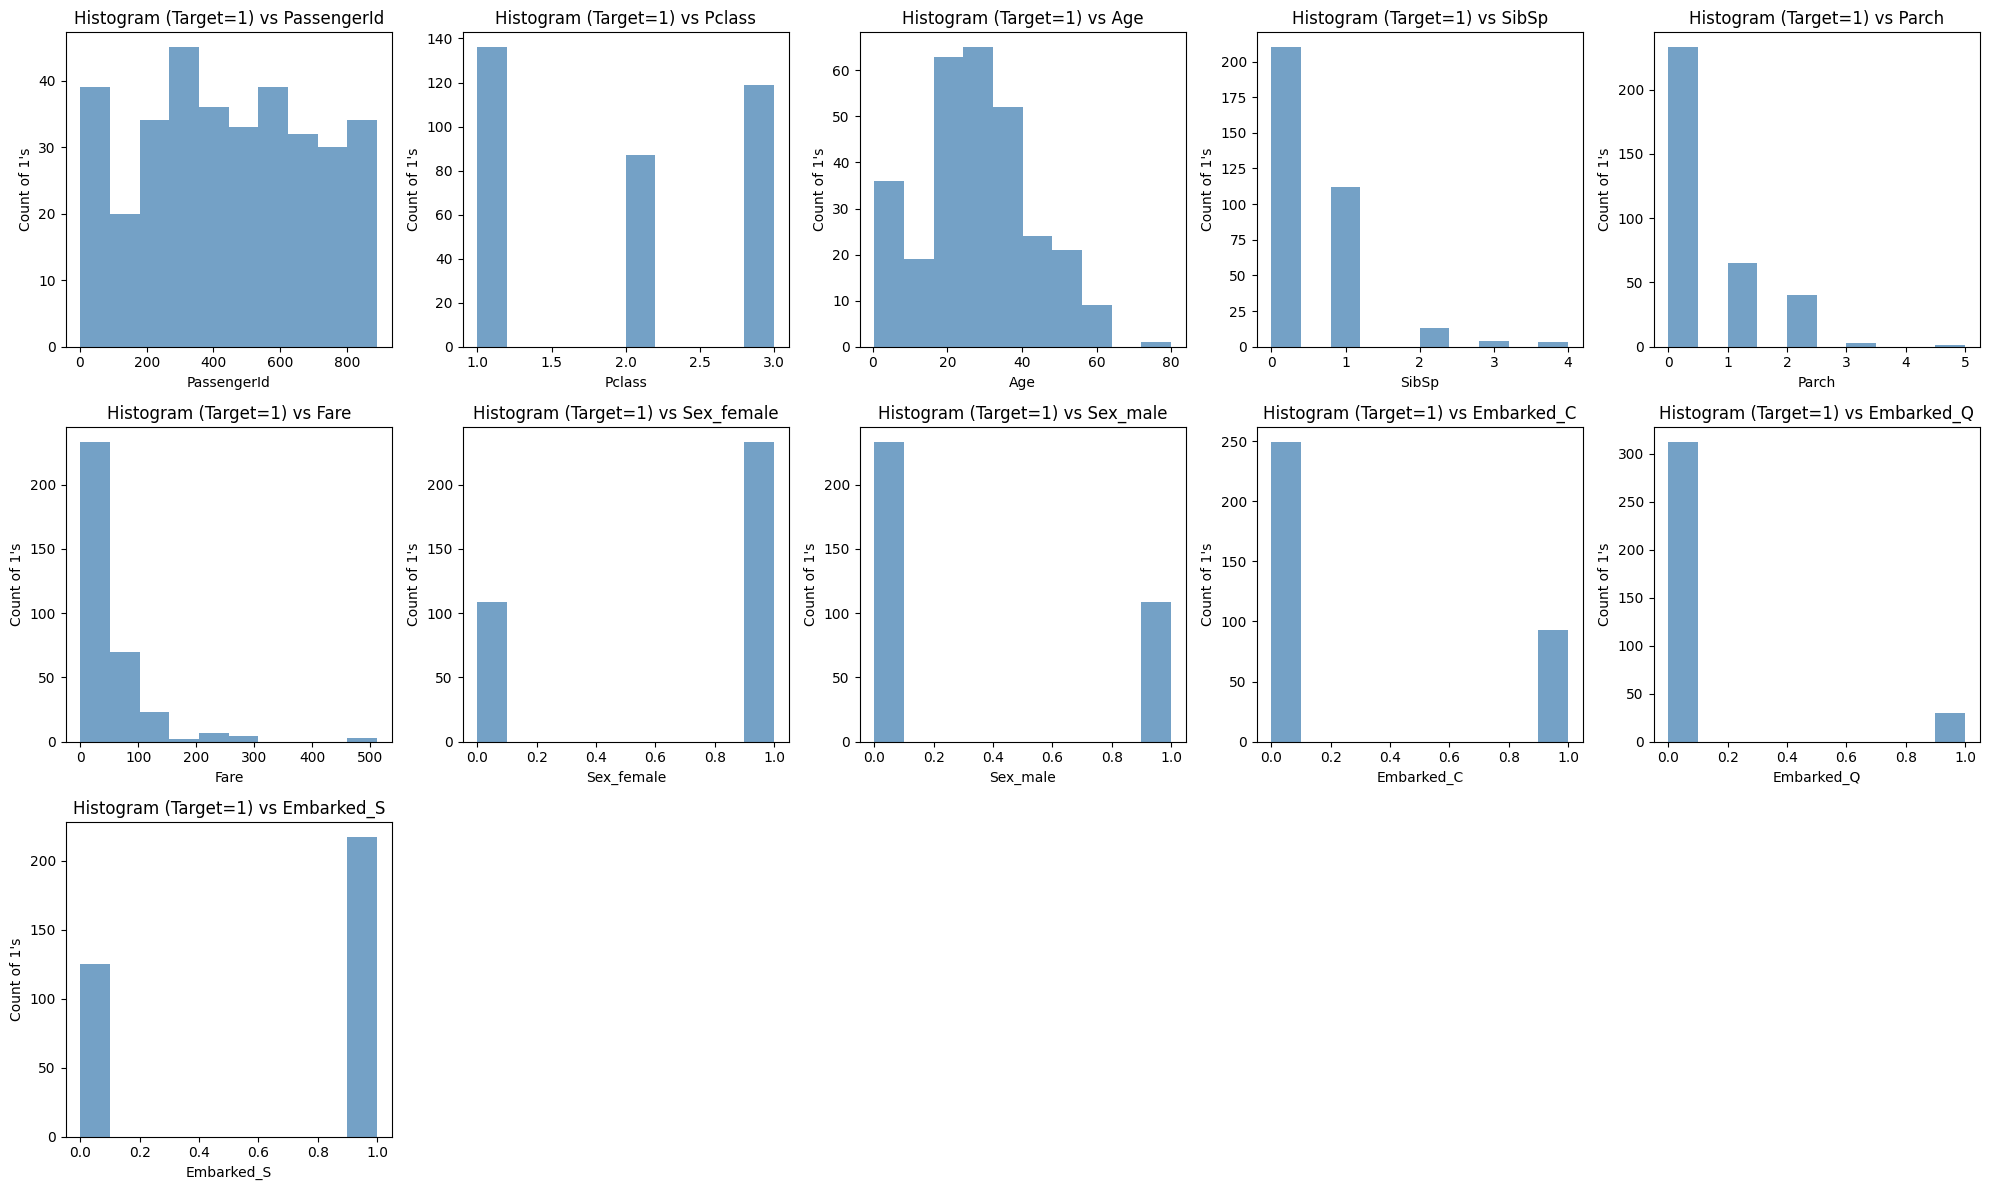

In [79]:

def histogram_ones_vs_columns(df, target_col, col_indexes=None, bins=10, charts_per_row=3):
    """
    Plots histograms showing the distribution of target==1 against 
    selected numeric columns (by index). If no indexes are provided,
    all numeric columns except the target column are used.

    Parameters:
    df : DataFrame
    target_col : str
        Name of the binary target column (0/1).
    col_indexes : list or None
        Column indexes to compare with. If None, all numeric columns are used.
    bins : int
        Number of histogram bins.
    charts_per_row : int
        Number of plots per row in the grid.
    """

    # Ensure binary
    if not set(df[target_col].dropna().unique()).issubset({0, 1}):
        raise ValueError("Target column must contain only 0 and 1.")

    # Determine which columns to use
    if col_indexes is None:
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        # all numeric except target
        cols = [col for col in numeric_cols if col != target_col]
        # convert to indexes for uniformity
        col_indexes = [df.columns.get_loc(col) for col in cols]

    # Convert indexes to column names
    cols = [df.columns[i] for i in col_indexes]

    # Take only rows where target == 1
    df_ones = df[df[target_col] == 1]

    num_plots = len(cols)
    rows = math.ceil(num_plots / charts_per_row)

    fig, axes = plt.subplots(rows, charts_per_row, figsize=(charts_per_row * 4, rows * 4))
    axes = axes.flatten()

    for idx, col in enumerate(cols):
        ax = axes[idx]

        # Ensure column is numeric
        if not pd.api.types.is_numeric_dtype(df[col]):
            try:
                df[col] = pd.to_numeric(df[col], errors='coerce')
            except:
                raise ValueError(f"Column '{col}' cannot be converted to numeric.")

        ax.hist(df_ones[col].dropna(), bins=bins, color='steelblue', alpha=0.75)
        ax.set_title(f"Histogram (Target=1) vs {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Count of 1's")

    # Turn off unused axes
    for j in range(idx + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

histogram_ones_vs_columns(train_data_encoded, 'Survived',charts_per_row=5)

In [80]:
train_data_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Age          714 non-null    float64
 4   SibSp        891 non-null    int64  
 5   Parch        891 non-null    int64  
 6   Fare         891 non-null    float64
 7   Sex_female   891 non-null    int64  
 8   Sex_male     891 non-null    int64  
 9   Embarked_C   891 non-null    int64  
 10  Embarked_Q   891 non-null    int64  
 11  Embarked_S   891 non-null    int64  
dtypes: float64(2), int64(10)
memory usage: 83.7 KB


In [81]:
x = train_data_encoded.drop(['PassengerId'], axis=1)
x.shape
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Age         714 non-null    float64
 3   SibSp       891 non-null    int64  
 4   Parch       891 non-null    int64  
 5   Fare        891 non-null    float64
 6   Sex_female  891 non-null    int64  
 7   Sex_male    891 non-null    int64  
 8   Embarked_C  891 non-null    int64  
 9   Embarked_Q  891 non-null    int64  
 10  Embarked_S  891 non-null    int64  
dtypes: float64(2), int64(9)
memory usage: 76.7 KB


In [82]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

def classification_models_pipeline(df, target_col="Attrition", test_size=0.2, random_state=42):
    """
    Complete ML pipeline including:
    - Numerical and categorical imputation
    - Scaling
    - Splitting
    - Logistic Regression / SVM / MLP
    - Cross-validation
    - Confusion matrices
    """

    X = df.drop(columns=[target_col])
    y = df[target_col]

    numeric_cols = X.select_dtypes(include=[np.number]).columns
    categorical_cols = X.select_dtypes(include=["object", "category", "string"]).columns

    # -----------------------------
    # Preprocessing Pipeline
    # -----------------------------
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="mean")),   # handle numeric NaNs
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),  # handle missing strings
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols)
        ]
    )

    # -----------------------------
    # Split into train/test
    # -----------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    # -----------------------------
    # Classifiers
    # -----------------------------
    classifiers = {
        "Logistic Regression": LogisticRegression(max_iter=500),
        "SVM (RBF Kernel)": SVC(kernel="rbf", probability=True),
        "Neural Network (MLP)": MLPClassifier(hidden_layer_sizes=(32,16,8), max_iter=1000)
    }

    results = {}

    # -----------------------------
    # Train & Evaluate
    # -----------------------------
    for name, model in classifiers.items():
        print(f"\n==============================")
        print(f"MODEL: {name}")
        print(f"==============================\n")

        pipe = Pipeline(steps=[
            ("preprocess", preprocessor),
            ("model", model)
        ])

        # Train
        pipe.fit(X_train, y_train)

        # Cross-validation
        cv_scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring="accuracy")

        print(f"Cross-Validation Accuracy: {cv_scores}")
        print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")

        # Predict
        y_pred = pipe.predict(X_test)

        # Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        cm_pct = cm / cm.sum() * 100

        print("\nConfusion Matrix (Counts):")
        print(cm)

        print("\nConfusion Matrix (%):")
        print(np.round(cm_pct, 2))

        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))

        results[name] = {
            "cv_scores": cv_scores,
            "mean_cv_accuracy": cv_scores.mean(),
            "confusion_matrix": cm,
            "confusion_matrix_percent": cm_pct
        }

    return results

results = classification_models_pipeline(x, target_col='Survived')
print(results)


MODEL: Logistic Regression

Cross-Validation Accuracy: [0.79020979 0.76223776 0.79577465 0.81690141 0.81690141]
Mean CV Accuracy: 0.7964

Confusion Matrix (Counts):
[[98 12]
 [23 46]]

Confusion Matrix (%):
[[54.75  6.7 ]
 [12.85 25.7 ]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179


MODEL: SVM (RBF Kernel)

Cross-Validation Accuracy: [0.82517483 0.81118881 0.84507042 0.82394366 0.81690141]
Mean CV Accuracy: 0.8245

Confusion Matrix (Counts):
[[103   7]
 [ 26  43]]

Confusion Matrix (%):
[[57.54  3.91]
 [14.53 24.02]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.94      0.86       110
           1       0.86      0.62    

In [83]:
def train_svm_and_predict(train_df, test_df, target_col="Attrition"):
    """
    Trains an SVM classifier on the full training set and predicts on a test set.

    Parameters:
    train_df : pandas DataFrame
        Training data including the target column.
    test_df : pandas DataFrame
        Test data on which to predict. Should have same features as train_df (except target).
    target_col : str
        Name of the target column in train_df.

    Returns:
    predictions : np.array
        Predicted labels for the test data.
    pipeline : Pipeline
        The trained pipeline (preprocessing + SVM).
    """

    # -------------------------------
    # 1. Split features and target
    # -------------------------------
    X_train = train_df.drop(columns=[target_col])
    y_train = train_df[target_col]

    X_test = test_df.copy()  # make sure test_df does not have target column

    # -------------------------------
    # 2. Identify numeric and categorical columns
    # -------------------------------
    numeric_cols = X_train.select_dtypes(include=[np.number]).columns
    categorical_cols = X_train.select_dtypes(include=["object", "category", "string"]).columns

    # -------------------------------
    # 3. Preprocessing pipeline
    # -------------------------------
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols)
        ]
    )

    # -------------------------------
    # 4. Create the full pipeline
    # -------------------------------
    svm_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("svm", SVC(kernel="rbf", probability=True))  # probability=True if you need probabilities
    ])

    # -------------------------------
    # 5. Train on full training data
    # -------------------------------
    svm_pipeline.fit(X_train, y_train)

    # -------------------------------
    # 6. Predict on test data
    # -------------------------------
    predictions = svm_pipeline.predict(X_test)

    return predictions, svm_pipeline


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [84]:
test_data = pd.read_csv('test.csv')
test_data = drop_columns(test_data, ['Cabin', 'Ticket','Name','PassengerId'])
test_data = one_hot_encode_by_index(test_data, [1,6])
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Pclass      418 non-null    int64  
 1   Age         332 non-null    float64
 2   SibSp       418 non-null    int64  
 3   Parch       418 non-null    int64  
 4   Fare        417 non-null    float64
 5   Sex_female  418 non-null    int64  
 6   Sex_male    418 non-null    int64  
 7   Embarked_C  418 non-null    int64  
 8   Embarked_Q  418 non-null    int64  
 9   Embarked_S  418 non-null    int64  
dtypes: float64(2), int64(8)
memory usage: 32.8 KB


In [86]:

predictions, svm_pipeline = train_svm_and_predict(x, test_data, target_col='Survived')
print(predictions)
print(len(predictions))

[0 0 0 0 0 0 1 0 1 0 0 0 1 0 1 1 0 0 0 1 0 1 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 1 1 0 0 0 1 0 0 0 1 1 0 0 0 0 0 1 0 0 0 1 0 1 1 0 0 0 1 0 0 0
 1 0 0 1 0 1 1 0 0 0 0 0 1 0 1 1 0 0 1 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0
 1 1 1 1 0 0 1 0 1 1 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 0 1 0 0 0 0 0 1 0 0 1 1 1 1 0 0 0 0 0 1 0 0 0 0 0 0 1 1 0 1 1 0 0 1 0 1
 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 1 1 0 1 0 0 1 0 1 0 0 0 0 1 0 0 1 0 1 0 1 0
 1 0 1 1 0 1 0 0 0 1 0 0 0 0 0 0 1 1 1 1 0 0 0 0 1 0 1 1 1 0 0 0 0 0 0 0 1
 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 1 0 0 0 0
 1 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0
 1 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 0 0 1 1 0 1 0 0 0 1 0
 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 1 0 0 1 0 1 0 0 1 0 1 0 0 0 0
 0 1 1 1 1 0 0 1 0 0 0]
418


In [89]:
def save_predictions_to_csv(predictions, start_id=892, filename="predictions.csv"):
    """
    Save predictions to CSV with PassengerId starting from start_id.

    Parameters:
    predictions : array-like
        List or array of predicted labels (0/1).
    start_id : int
        Starting PassengerId.
    filename : str
        Name of the CSV file to save.
    """

    # Create PassengerId sequence
    passenger_ids = list(range(start_id, start_id + len(predictions)))

    # Create DataFrame
    df_out = pd.DataFrame({
        "PassengerId": passenger_ids,
        "Survived": predictions
    })

    # Save to CSV
    df_out.to_csv(filename, index=False)
    print(f"Predictions saved to {filename}")

save_predictions_to_csv(predictions, start_id=892, filename="predictions.csv")

Predictions saved to predictions.csv
